# SST in Mar 2023 in HRDPS and CaSR Driven Results

## Basic Information

In [ ]:
# Paths 

import xarray as xr



ds_bio_casr=xr.open_dataset(path_bio_casr)
ds_bio_hrdps=xr.open_dataset(path_bio_hrdps)

### Bio Variables (Not used here)

In [ ]:
# Datasets information

# print(ds_bio_casr)
print(list(ds_bio_casr.data_vars))


['bounds_nav_lon', 'bounds_nav_lat', 'area', 'deptht_bounds', 'time_centered_bounds', 'time_counter_bounds', 'nitrate', 'ammonium', 'silicon', 'diatoms', 'flagellates', 'microzooplankton', 'dissolved_organic_nitrogen', 'particulate_organic_nitrogen', 'biogenic_silicon', 'mesozooplankton']


In [ ]:
print(ds_bio_casr)

<xarray.Dataset> Size: 18GB
Dimensions:                       (y: 898, x: 398, nvertex: 4, deptht: 40,
                                   axis_nbounds: 2, time_counter: 31)
Coordinates:
    nav_lat                       (y, x) float32 1MB ...
    nav_lon                       (y, x) float32 1MB ...
  * deptht                        (deptht) float32 160B 0.5 1.5 ... 414.5 441.5
    time_centered                 (time_counter) datetime64[ns] 248B ...
  * time_counter                  (time_counter) datetime64[ns] 248B 2023-03-...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables: (12/16)
    bounds_nav_lon                (y, x, nvertex) float32 6MB ...
    bounds_nav_lat                (y, x, nvertex) float32 6MB ...
    area                          (y, x) float32 1MB ...
    deptht_bounds                 (deptht, axis_nbounds) float32 320B ...
    time_centered_bounds          (time_counter, axis_nbounds) datetime64[ns] 496B ...
    time_counter_bounds         

**Interesting variables**
    Nitrate: `'nitrate'`
    Diatoms: `'diatoms'`
    Flagellates: `'flagellates'`


### Depths

In [ ]:
print(ds_bio_casr['deptht'])

<xarray.DataArray 'deptht' (deptht: 40)> Size: 160B
array([  0.5     ,   1.500003,   2.500011,   3.500031,   4.500071,   5.500151,
         6.50031 ,   7.500623,   8.501236,   9.502433,  10.504766,  11.509312,
        12.518167,  13.535412,  14.568982,  15.634288,  16.761173,  18.007135,
        19.481785,  21.389978,  24.100256,  28.229916,  34.685757,  44.517723,
        58.484333,  76.58559 ,  98.06296 , 121.866516, 147.08946 , 173.11449 ,
       199.57304 , 226.2603  , 253.06664 , 279.93454 , 306.8342  , 333.75018 ,
       360.67453 , 387.6032  , 414.5341  , 441.4661  ], dtype=float32)
Coordinates:
  * deptht   (deptht) float32 160B 0.5 1.5 2.5 3.5 ... 360.7 387.6 414.5 441.5
Attributes:
    name:       deptht
    long_name:  Vertical T levels
    units:      m
    positive:   down
    bounds:     deptht_bounds


**Top 20m = Top 19 layers (0-18)**

**Top 10m = Top 10 layers (0-9)**

### Interesting Locations

1. **Howe Sound - Pam Rocks**, British Columbia: Latitude 49.49° N | Longitude 123.3° W, inlet
    
    y index = 502
    x index = 341

    from https://weather.gc.ca/past_conditions/index_e.html?station=was 

2. **Sand Heads Lightstation**, British Columbia Latitude 49.11° N | Longitude 123.3° W, fraser river

    y index = 428
    x index = 293

    from https://weather.gc.ca/past_conditions/index_e.html?station=wvf

3. **North SoG**: (49.9, -124.8)

    y index = 689
    x index = 172

    from biol report

4. **Mid SoG**: (49.3, -124.0)

    y index = 515
    x index = 215
    
    from biol report

5. **South SoG**: (49.0, -123.25)
  
    y index = 403
    x index = 287
    
    from biol report



In [13]:
# find grid point number

import numpy as np
import xarray as xr

# load T grid
ds = ds_bio_casr

lat = ds.nav_lat.values
lon = ds.nav_lon.values

locations = {
    "Pam Rocks": {49.49, -123.3},
    "Sand Heads": {49.11, -123.3},
    "SoG North": (49.9, -124.8),
    "SoG Central": (49.3, -124),
    "SoG South":    (49, -123.25),
}

for name, (target_lat, target_lon) in locations.items():

    # simple squared distance in lat/lon space
    dist2 = (lat - target_lat)**2 + (lon - target_lon)**2

    # find nearest grid point
    j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)

    print(name)
    print("  y index =", j)
    print("  x index =", i)
    print("  grid lat =", lat[j, i])
    print("  grid lon =", lon[j, i])
    print()

Pam Rocks
  y index = 502
  x index = 341
  grid lat = 49.487434
  grid lon = -123.30153

Sand Heads
  y index = 428
  x index = 293
  grid lat = 49.107586
  grid lon = -123.30203

SoG North
  y index = 689
  x index = 172
  grid lat = 49.900864
  grid lon = -124.80089

SoG Central
  y index = 515
  x index = 215
  grid lat = 49.301468
  grid lon = -123.99817

SoG South
  y index = 403
  x index = 287
  grid lat = 48.998005
  grid lon = -123.24935



### Map of Locations

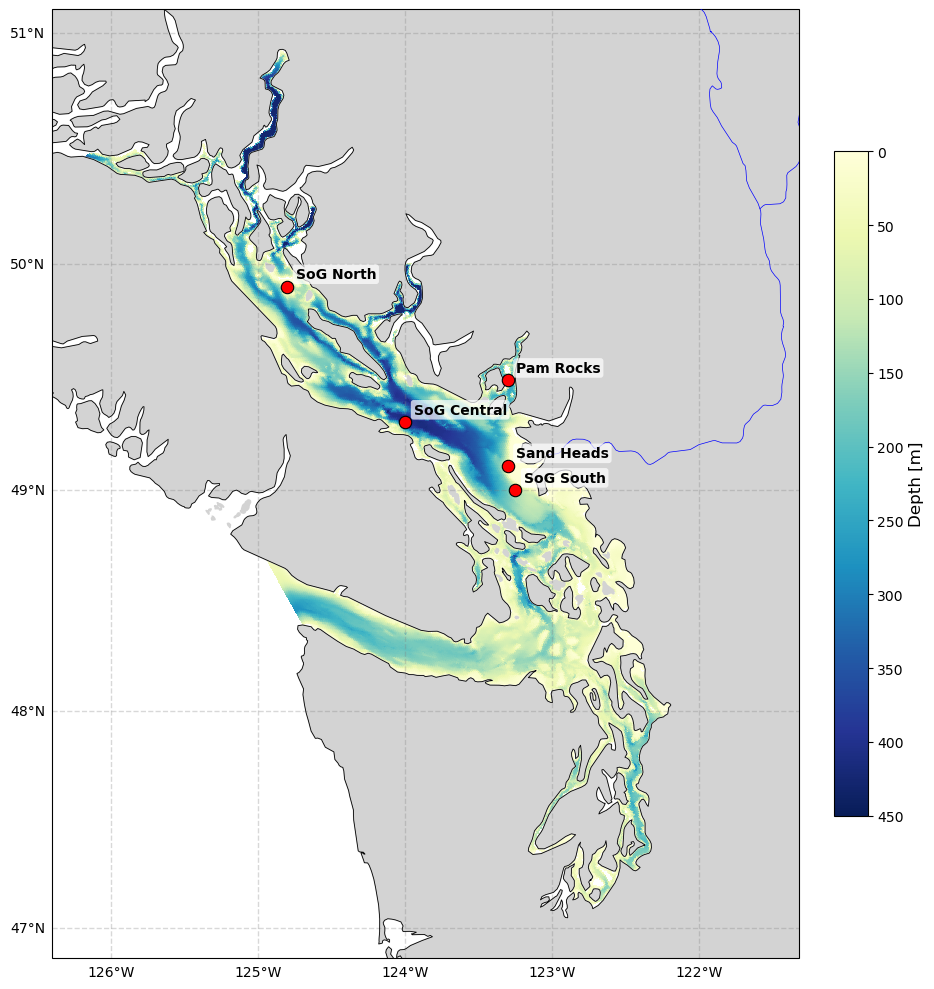

In [15]:
# Bathy plot

# Bathy plot with stations

import netCDF4 as nc
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# ---------------------------------------------------------
# 1. 读取 bathymetry 文件
# ---------------------------------------------------------
file_path = "/data/nsoontie/MEOPAR/NEMO-forcing/grid/bathy_meter_SalishSea2.nc"

with nc.Dataset(file_path, 'r') as ds:
    lons = ds.variables['nav_lon'][:]
    lats = ds.variables['nav_lat'][:]
    bathy = ds.variables['Bathymetry'][:]

# ---------------------------------------------------------
# 2. 定义站点
# ---------------------------------------------------------
stations = {
    "Pam Rocks": {
        "y": 502,
        "x": 341,
        "lat": 49.487434,
        "lon": -123.30153,
    },
    "Sand Heads": {
        "y": 428,
        "x": 293,
        "lat": 49.107586,
        "lon": -123.30203,
    },
    "SoG North": {
        "y": 689,
        "x": 172,
        "lat": 49.900864,
        "lon": -124.80089,
    },
    "SoG Central": {
        "y": 515,
        "x": 215,
        "lat": 49.301468,
        "lon": -123.99817,
    },
    "SoG South": {
        "y": 403,
        "x": 287,
        "lat": 48.998005,
        "lon": -123.24935,
    },
}

# ---------------------------------------------------------
# 3. 创建画布
# ---------------------------------------------------------
fig = plt.figure(figsize=(12, 10))

ax = plt.axes(projection=ccrs.Mercator())

# ---------------------------------------------------------
# 4. 绘制水深
# ---------------------------------------------------------
pcm = ax.pcolormesh(
    lons,
    lats,
    bathy,
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu',
    shading='auto',
    vmin=0,
    vmax=450,
    zorder=1
)

# colorbar
cbar = plt.colorbar(
    pcm,
    ax=ax,
    orientation='vertical',
    pad=0.03,
    shrink=0.7
)

cbar.set_label('Depth [m]', fontsize=12)

# 浅水在上，深水在下
cbar.ax.invert_yaxis()

# ---------------------------------------------------------
# 5. 地图特征
# ---------------------------------------------------------
land_10m = cfeature.NaturalEarthFeature(
    'physical',
    'land',
    '10m',
    edgecolor='face',
    facecolor='lightgray'
)

ax.add_feature(land_10m, zorder=2)

ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    zorder=3
)

ax.add_feature(
    cfeature.RIVERS.with_scale('10m'),
    linewidth=0.5,
    edgecolor='blue',
    zorder=3
)

# ---------------------------------------------------------
# 6. 绘制站点
# ---------------------------------------------------------
for name, info in stations.items():

    lon = info["lon"]
    lat = info["lat"]

    # 站点位置
    ax.scatter(
        lon,
        lat,
        s=80,
        marker='o',
        facecolor='red',
        edgecolor='black',
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=10
    )

    # 站点名称
    ax.annotate(
        name,
        xy=(lon, lat),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='black',
        transform=ccrs.PlateCarree(),
        zorder=11,
        bbox=dict(
            boxstyle='round,pad=0.2',
            facecolor='white',
            edgecolor='none',
            alpha=0.7
        )
    )

# ---------------------------------------------------------
# 7. 网格线和经纬度标签
# ---------------------------------------------------------
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=1,
    color='gray',
    alpha=0.3,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# ---------------------------------------------------------
# 8. 显示范围
# ---------------------------------------------------------
ax.set_extent(
    [
        lons.min(),
        lons.max(),
        lats.min(),
        lats.max()
    ],
    crs=ccrs.PlateCarree()
)


plt.tight_layout()
plt.show()

## SST Map and Time Series

### SST Map

Date        : 20230301
Time index  : 0
CaSR time   : 2023-03-01T12:00:00.000000000
HRDPS time  : 2023-03-01T12:00:00.000000000
CaSR shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230315
Time index  : 14
CaSR time   : 2023-03-15T12:00:00.000000000
HRDPS time  : 2023-03-15T12:00:00.000000000
CaSR shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230331
Time index  : 30
CaSR time   : 2023-03-31T12:00:00.000000000
HRDPS time  : 2023-03-31T12:00:00.000000000
CaSR shape  : (898, 398)
HRDPS shape : (898, 398)

Color ranges:
SST  : 0.000 to 10.976 °C
Diff : -2.950 to 2.950 °C


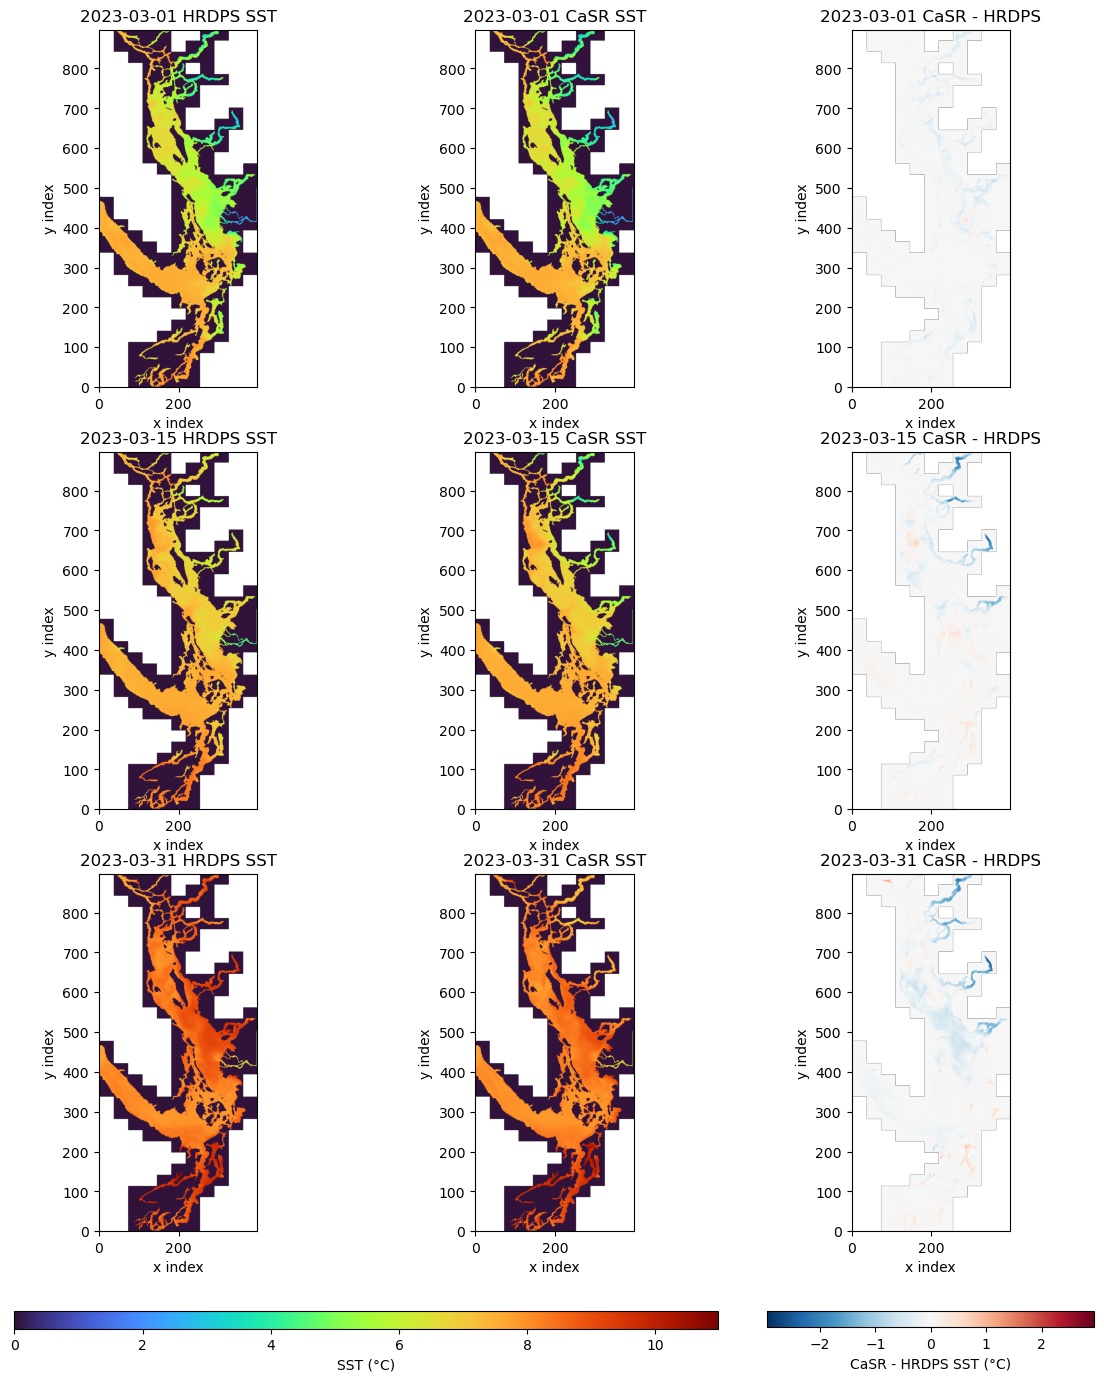

In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# 1d grid_T files
# ============================================================
path_grid_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_grid_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_grid_casr)
hrdps_ds = xr.open_dataset(path_grid_hrdps)


# ============================================================
# Choose 3 days
#
# For 1d monthly files:
# March 1  -> time index 0
# March 15 -> time index 14
# March 31 -> time index 30
# ============================================================
days = [
    "20230301",
    "20230315",
    "20230331",
]

day_numbers = [1, 15, 31]

depth_idx = 0


# ============================================================
# Read SST data
# ============================================================
all_data = []

for date_str, day_num in zip(days, day_numbers):

    # ========================================================
    # Time index for 1d monthly file
    # ========================================================
    tidx = day_num - 1


    # ========================================================
    # SST
    # ========================================================
    casr_sst = casr_ds['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values

    hrdps_sst = hrdps_ds['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values


    # ========================================================
    # Difference
    # positive = CaSR warmer than HRDPS
    # ========================================================
    diff = casr_sst - hrdps_sst


    # ========================================================
    # Time information
    # ========================================================
    casr_time = casr_ds.time_counter.isel(
        time_counter=tidx
    ).values

    hrdps_time = hrdps_ds.time_counter.isel(
        time_counter=tidx
    ).values


    print("=" * 60)
    print(f"Date        : {date_str}")
    print(f"Time index  : {tidx}")
    print(f"CaSR time   : {casr_time}")
    print(f"HRDPS time  : {hrdps_time}")
    print(f"CaSR shape  : {casr_sst.shape}")
    print(f"HRDPS shape : {hrdps_sst.shape}")


    # ========================================================
    # Save for plotting
    # ========================================================
    all_data.append({
        'date': date_str,
        'hrdps': hrdps_sst,
        'casr': casr_sst,
        'diff': diff,
    })


# ============================================================
# Unified SST color range
# across all 3 days and both datasets
# ============================================================
all_sst_values = []

for data in all_data:

    all_sst_values.append(
        data['hrdps'][np.isfinite(data['hrdps'])]
    )

    all_sst_values.append(
        data['casr'][np.isfinite(data['casr'])]
    )

all_sst_values = np.concatenate(all_sst_values)

sst_vmin = np.nanmin(all_sst_values)
sst_vmax = np.nanmax(all_sst_values)


# ============================================================
# Unified difference color range
# symmetric around zero
# ============================================================
all_diff_values = []

for data in all_data:

    all_diff_values.append(
        data['diff'][np.isfinite(data['diff'])]
    )

all_diff_values = np.concatenate(all_diff_values)

diff_max = np.nanmax(np.abs(all_diff_values))

diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)


print("\nColor ranges:")
print(f"SST  : {sst_vmin:.3f} to {sst_vmax:.3f} °C")
print(f"Diff : {-diff_max:.3f} to {diff_max:.3f} °C")


# ============================================================
# Plot: 3 rows × 3 columns
#
# column 1: HRDPS SST
# column 2: CaSR SST
# column 3: CaSR - HRDPS
# ============================================================
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 16)
)


for row, data in enumerate(all_data):

    date_str = data['date']

    hrdps_sst = data['hrdps']
    casr_sst = data['casr']
    diff = data['diff']

    date_label = (
        f'{date_str[:4]}-'
        f'{date_str[4:6]}-'
        f'{date_str[6:]}'
    )


    # ========================================================
    # HRDPS SST
    # ========================================================
    im_sst = axes[row, 0].imshow(
        hrdps_sst,
        origin='lower',
        cmap='turbo',
        vmin=sst_vmin,
        vmax=sst_vmax,
        aspect='equal'
    )

    axes[row, 0].set_title(
        f'{date_label} HRDPS SST'
    )

    axes[row, 0].set_xlabel('x index')
    axes[row, 0].set_ylabel('y index')


    # ========================================================
    # CaSR SST
    # ========================================================
    axes[row, 1].imshow(
        casr_sst,
        origin='lower',
        cmap='turbo',
        vmin=sst_vmin,
        vmax=sst_vmax,
        aspect='equal'
    )

    axes[row, 1].set_title(
        f'{date_label} CaSR SST'
    )

    axes[row, 1].set_xlabel('x index')
    axes[row, 1].set_ylabel('y index')


    # ========================================================
    # Difference
    # ========================================================
    im_diff = axes[row, 2].imshow(
        diff,
        origin='lower',
        cmap='RdBu_r',
        norm=diff_norm,
        aspect='equal'
    )

    axes[row, 2].set_title(
        f'{date_label} CaSR - HRDPS'
    )

    axes[row, 2].set_xlabel('x index')
    axes[row, 2].set_ylabel('y index')


# ============================================================
# Adjust space
# leave space at bottom for horizontal colorbars
# ============================================================
plt.subplots_adjust(
    left=0.07,
    right=0.97,
    top=0.95,
    bottom=0.12,
    wspace=0.15,
    hspace=0.18
)


# ============================================================
# SST colorbar
# shared by first two columns
# ============================================================
cbar_sst = fig.colorbar(
    im_sst,
    ax=axes[:, 0:2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=40
)

cbar_sst.set_label('SST (°C)')


# ============================================================
# Difference colorbar
# shared by third column
# ============================================================
cbar_diff = fig.colorbar(
    im_diff,
    ax=axes[:, 2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=20
)

cbar_diff.set_label('CaSR - HRDPS SST (°C)')


plt.show()


# ============================================================
# Close files
# ============================================================
casr_ds.close()
hrdps_ds.close()

### Temperature Profiles and Time Series

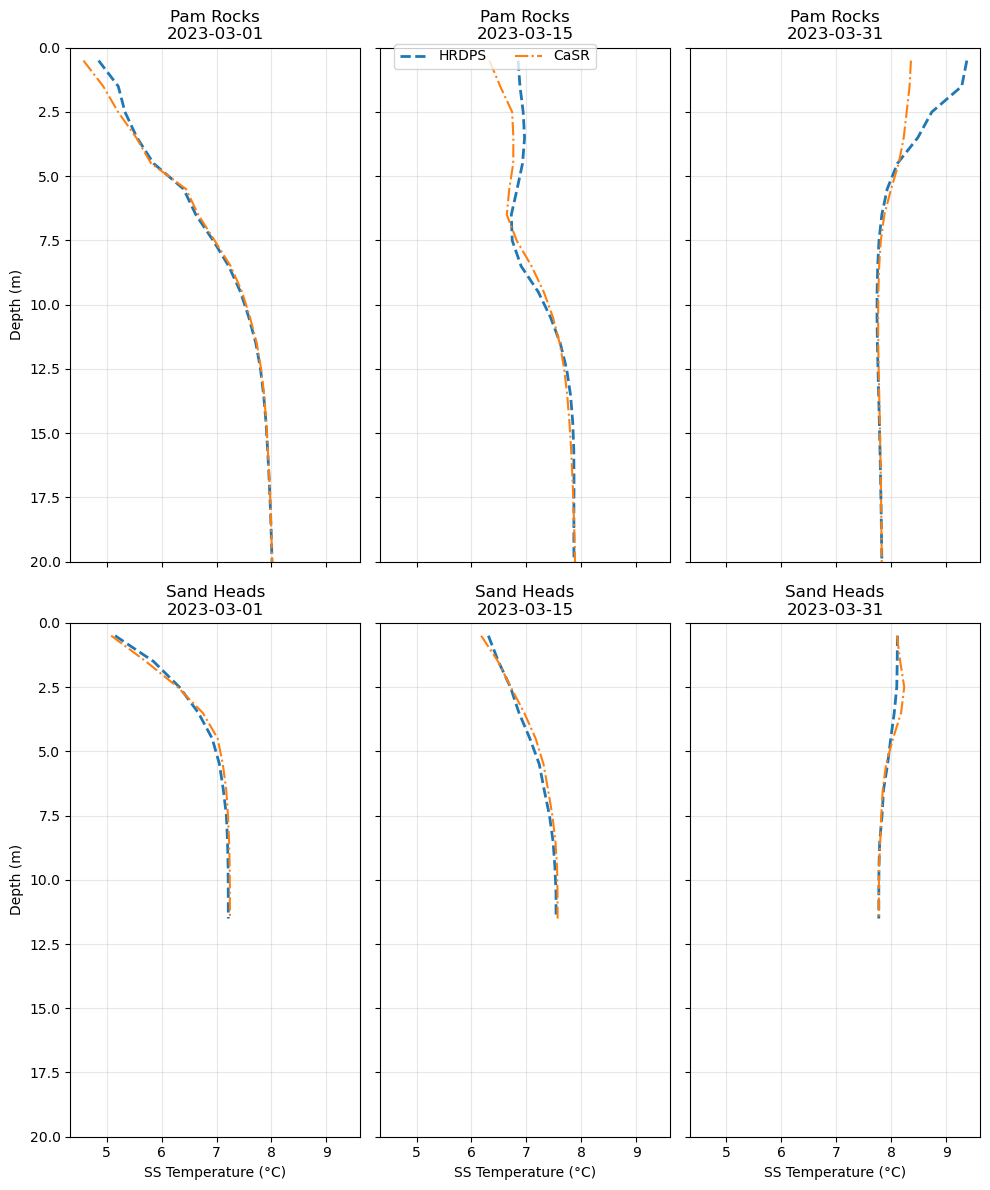

In [20]:
# Temperature Profile


import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================
path_grid_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_grid_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_grid_casr)
hrdps_ds = xr.open_dataset(path_grid_hrdps)


# ============================================================
# Stations
# ============================================================
stations = [
    {
        'name': 'Pam Rocks',
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },
    {
        'name': 'Sand Heads',
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
]


# ============================================================
# Dates
# ============================================================
days = [1, 15, 31]


# ============================================================
# Depth
# ============================================================
depth = casr_ds['deptht'].values


# ============================================================
# Read all profiles
#
# Order:
# Pam Rocks:  Mar 1, Mar 15, Mar 31
# Sand Heads: Mar 1, Mar 15, Mar 31
# ============================================================
profiles = []

for station in stations:

    for day in days:

        tidx = day - 1

        casr_profile = casr_ds['votemper'].isel(
            time_counter=tidx,
            y=station['y'],
            x=station['x']
        ).values

        hrdps_profile = hrdps_ds['votemper'].isel(
            time_counter=tidx,
            y=station['y'],
            x=station['x']
        ).values


        # ====================================================
        # Mask bad values
        #
        # Keep only levels where:
        # 1. depth is finite
        # 2. both datasets are finite
        # 3. temperature is not zero
        #
        # The zero test is useful if bottom/land values
        # were stored as 0 instead of NaN.
        # ====================================================
        valid = (
            np.isfinite(depth)
            & np.isfinite(casr_profile)
            & np.isfinite(hrdps_profile)
            & (casr_profile != 0)
            & (hrdps_profile != 0)
        )


        profiles.append({
            'station': station['name'],
            'day': day,
            'depth': depth[valid],
            'hrdps': hrdps_profile[valid],
            'casr': casr_profile[valid],
        })


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 12),
    sharex=True,
    sharey=True
)

axes = axes.flatten()


for ax, data in zip(axes, profiles):

    profile_depth = data['depth']


    ax.plot(
        data['hrdps'],
        profile_depth,
        linewidth=2,
        label='HRDPS',
        linestyle='--'
    )

    ax.plot(
        data['casr'],
        profile_depth,
        linewidth=1.5,
        label='CaSR',
        linestyle='-.'
    )


    # ========================================================
    # Title
    # ========================================================
    ax.set_title(
        f"{data['station']}\n"
        f"2023-03-{data['day']:02d}"
    )


    ax.grid(alpha=0.3)


# ============================================================
# Reverse depth axis
#
# Explicitly set the displayed depth range:
# surface at top, 20 m at bottom
# ============================================================
for ax in axes:
    ax.set_ylim(20, 0)


# ============================================================
# Labels
#
# bottom row = axes 3, 4, 5
# left column = axes 0, 3
# ============================================================
for ax in axes[3:]:
    ax.set_xlabel('SS Temperature (°C)')

for ax in axes[::3]:
    ax.set_ylabel('Depth (m)')


# ============================================================
# Shared legend
# ============================================================
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 0.965)
)




plt.tight_layout()

plt.show()


# ============================================================
# Close datasets
# ============================================================
casr_ds.close()
hrdps_ds.close()



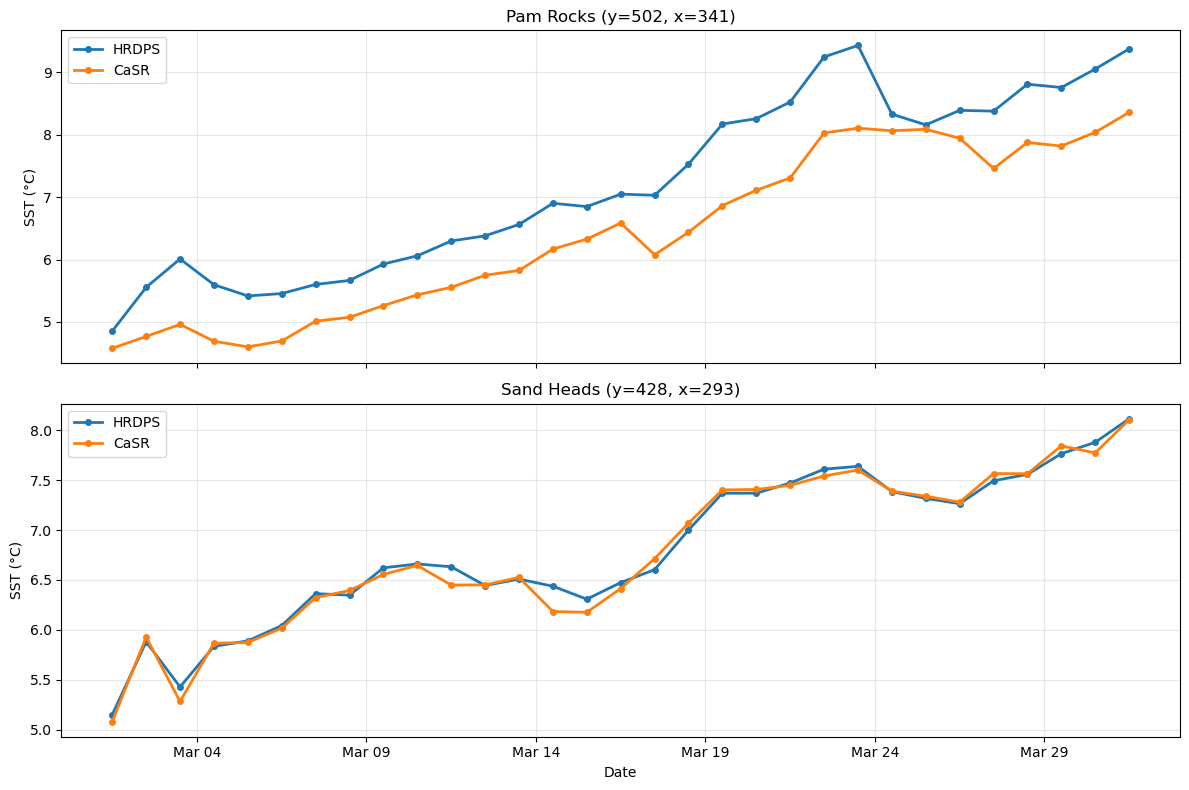

In [ ]:
# SST Time Series

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# Paths: 1d grid_T
# ============================================================
path_grid_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_grid_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_grid_casr)
hrdps_ds = xr.open_dataset(path_grid_hrdps)


# ============================================================
# Stations
# ============================================================
stations = {
    'Pam Rocks': {
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    'Sand Heads': {
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
}


# ============================================================
# Surface layer
# ============================================================
depth_idx = 0


# ============================================================
# Time
# ============================================================
casr_time = casr_ds['time_counter'].values
hrdps_time = hrdps_ds['time_counter'].values


# ============================================================
# Plot
#
# one panel for each station
# ============================================================
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True
)


for ax, (station_name, station) in zip(
    axes,
    stations.items()
):

    y_idx = station['y']
    x_idx = station['x']


    # ========================================================
    # CaSR daily SST
    # ========================================================
    casr_sst = casr_ds['votemper'].isel(
        deptht=depth_idx,
        y=y_idx,
        x=x_idx
    ).values


    # ========================================================
    # HRDPS daily SST
    # ========================================================
    hrdps_sst = hrdps_ds['votemper'].isel(
        deptht=depth_idx,
        y=y_idx,
        x=x_idx
    ).values


    # ========================================================
    # Plot
    # ========================================================
    ax.plot(
        hrdps_time,
        hrdps_sst,
        marker='o',
        markersize=4,
        linewidth=2,
        label='HRDPS'
    )

    ax.plot(
        casr_time,
        casr_sst,
        marker='o',
        markersize=4,
        linewidth=2,
        label='CaSR'
    )


    # ========================================================
    # Station title
    # ========================================================
    ax.set_title(
        f"{station_name} "
        f"(y={y_idx}, x={x_idx})"
    )


    # ========================================================
    # Labels
    # ========================================================
    ax.set_ylabel('SST (°C)')


    # ========================================================
    # Grid
    # ========================================================
    ax.grid(
        True,
        alpha=0.3
    )


    # ========================================================
    # Legend
    # ========================================================
    ax.legend()


# ============================================================
# Date axis
# ============================================================
axes[-1].set_xlabel('Date')

axes[-1].xaxis.set_major_locator(
    mdates.DayLocator(interval=5)
)

axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter('%b %d')
)



plt.tight_layout()

plt.show()


# ============================================================
# Close datasets
# ============================================================
casr_ds.close()
hrdps_ds.close()

## Forcing Differences

Try compare the air temperature, solar radiation and wind speed near the locations.

### Find out the grid points for forcing fields

In [2]:
import xarray as xr

path_forcing_casr_01='/ocean/jqiu/forcings/CaSR/CaSR_y2023m03d01.nc'
path_forcing_hrdps_01='/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2023m03d01.nc'

ds_forcing_casr_01=xr.open_dataset(path_forcing_casr_01)
ds_forcing_hrdps_01=xr.open_dataset(path_forcing_hrdps_01)


In [3]:
print(ds_forcing_casr_01)

<xarray.Dataset> Size: 6MB
Dimensions:       (time_counter: 24, y: 105, x: 70)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 192B 2023-03-01 ... 2023-03-0...
  * y             (y) int32 420B 0 1 2 3 4 5 6 7 ... 98 99 100 101 102 103 104
  * x             (x) int32 280B 0 1 2 3 4 5 6 7 8 ... 62 63 64 65 66 67 68 69
    nav_lat       (y, x) float32 29kB ...
    nav_lon       (y, x) float32 29kB ...
Data variables:
    solar         (time_counter, y, x) float32 706kB ...
    precip        (time_counter, y, x) float32 706kB ...
    therm_rad     (time_counter, y, x) float32 706kB ...
    tair          (time_counter, y, x) float32 706kB ...
    qair          (time_counter, y, x) float32 706kB ...
    u_wind        (time_counter, y, x) float32 706kB ...
    atmpres       (time_counter, y, x) float32 706kB ...
    v_wind        (time_counter, y, x) float32 706kB ...
    percentcloud  (time_counter, y, x) float32 706kB ...
Attributes:
    title:           Converted CaSR atmosphe

In [4]:
print(ds_forcing_hrdps_01)

<xarray.Dataset> Size: 55MB
Dimensions:           (time_counter: 24, y: 230, x: 190)
Coordinates:
  * y                 (y) int64 2kB 0 1 2 3 4 5 6 ... 224 225 226 227 228 229
  * x                 (x) int64 2kB 0 1 2 3 4 5 6 ... 184 185 186 187 188 189
  * time_counter      (time_counter) datetime64[ns] 192B 2023-03-01 ... 2023-...
    nav_lon           (y, x) float64 350kB ...
    nav_lat           (y, x) float64 350kB ...
Data variables:
    LHTFL_surface     (time_counter, y, x) float32 4MB ...
    PRATE_surface     (time_counter, y, x) float32 4MB ...
    RH_2maboveground  (time_counter, y, x) float32 4MB ...
    atmpres           (time_counter, y, x) float32 4MB ...
    precip            (time_counter, y, x) float32 4MB ...
    qair              (time_counter, y, x) float32 4MB ...
    solar             (time_counter, y, x) float32 4MB ...
    tair              (time_counter, y, x) float32 4MB ...
    therm_rad         (time_counter, y, x) float32 4MB ...
    u_wind            (t

In [5]:
# find nearest grid point

import numpy as np

locations = {
    "Pam Rocks": (49.49, -123.3),
    "Sand Heads": (49.11, -123.3),
}

datasets = {
    "CaSR": ds_forcing_casr_01,
    "HRDPS": ds_forcing_hrdps_01,
}

for ds_name, ds in datasets.items():

    lat = ds.nav_lat.values
    lon = ds.nav_lon.values

    print(f"\n===== {ds_name} =====")

    for name, (target_lat, target_lon) in locations.items():

        # convert longitude from [-180, 180] to [0, 360]
        target_lon = target_lon + 360

        # simple squared distance in lat/lon space
        dist2 = (lat - target_lat)**2 + (lon - target_lon)**2

        # find nearest grid point
        j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)

        print(name)
        print("  y index =", j)
        print("  x index =", i)
        print("  grid lat =", lat[j, i])
        print("  grid lon =", lon[j, i])
        print()


===== CaSR =====
Pam Rocks
  y index = 58
  x index = 36
  grid lat = 49.483242
  grid lon = 236.67609

Sand Heads
  y index = 54
  x index = 34
  grid lat = 49.08101
  grid lon = 236.67067


===== HRDPS =====
Pam Rocks
  y index = 135
  x index = 110
  grid lat = 49.481496
  grid lon = 236.694728

Sand Heads
  y index = 119
  x index = 108
  grid lat = 49.118712
  grid lon = 236.693408



In [7]:
# Extract forcing data at 2 locations

import xarray as xr
import pandas as pd
from pathlib import Path
import glob


# ============================================================
# 1. Paths
# ============================================================

casr_dir = Path("/ocean/jqiu/forcings/CaSR")
hrdps_dir = Path(
    "/results/forcing/atmospheric/continental2.5/nemo_forcing"
)

casr_files = sorted(
    glob.glob(str(casr_dir / "CaSR_y2023m03d*.nc"))
)

hrdps_files = sorted(
    glob.glob(str(hrdps_dir / "hrdps_y2023m03d*.nc"))
)

print(f"CaSR files  : {len(casr_files)}")
print(f"HRDPS files : {len(hrdps_files)}")


# ============================================================
# 2. Only read these variables
# ============================================================

forcing_vars = [
    "solar",
    "precip",
    "therm_rad",
    "tair",
    "qair",
    "u_wind",
    "atmpres",
    "v_wind",
]


# ============================================================
# 3. Grid indices
# ============================================================

stations = {
    "PamRocks": {
        "CaSR": {
            "y": 58,
            "x": 36,
        },
        "HRDPS": {
            "y": 135,
            "x": 110,
        },
    },

    "SandHeads": {
        "CaSR": {
            "y": 54,
            "x": 34,
        },
        "HRDPS": {
            "y": 119,
            "x": 108,
        },
    },
}


# ============================================================
# 4. Open March 2023 datasets
# ============================================================

ds_casr = xr.open_mfdataset(
    casr_files,
    combine="by_coords",
    parallel=True,
    chunks={"time_counter": 24},
)[forcing_vars]

ds_hrdps = xr.open_mfdataset(
    hrdps_files,
    combine="by_coords",
    parallel=True,
    chunks={"time_counter": 24},
)[forcing_vars]


# print("\nCaSR:")
# print(ds_casr)

# print("\nHRDPS:")
# print(ds_hrdps)


# ============================================================
# 5. Function for extracting one grid point
# ============================================================

def save_grid_point_csv(
    ds,
    forcing_name,
    station_name,
    y_idx,
    x_idx,
    output_file,
):

    # --------------------------------------------------------
    # Extract specified grid point
    # --------------------------------------------------------

    point = ds[forcing_vars].isel(
        y=y_idx,
        x=x_idx,
    )

    # --------------------------------------------------------
    # Grid coordinates
    # --------------------------------------------------------

    grid_lat = float(
        ds["nav_lat"].isel(
            y=y_idx,
            x=x_idx,
        ).values
    )

    grid_lon = float(
        ds["nav_lon"].isel(
            y=y_idx,
            x=x_idx,
        ).values
    )

    # convert 0--360 longitude to -180--180
    grid_lon_180 = (
        grid_lon - 360
        if grid_lon > 180
        else grid_lon
    )

    # print(
    #     f"\n{forcing_name} - {station_name}"
    # )

    # print(
    #     f"y = {y_idx}, x = {x_idx}"
    # )

    # print(
    #     f"lat = {grid_lat:.6f}, "
    #     f"lon = {grid_lon:.6f}, "
    #     f"lon180 = {grid_lon_180:.6f}"
    # )

    # --------------------------------------------------------
    # Convert to DataFrame
    # --------------------------------------------------------

    df = point.to_dataframe().reset_index()

    # Remove x/y if xarray puts them into dataframe
    for col in ["x", "y"]:
        if col in df.columns:
            df = df.drop(columns=col)

    # --------------------------------------------------------
    # Add grid information
    # --------------------------------------------------------

    df["grid_y"] = y_idx
    df["grid_x"] = x_idx
    df["grid_lat"] = grid_lat
    df["grid_lon"] = grid_lon
    df["grid_lon_180"] = grid_lon_180

    # --------------------------------------------------------
    # Desired column order
    # --------------------------------------------------------

    columns = [
        "time_counter",
        "grid_y",
        "grid_x",
        "grid_lat",
        "grid_lon",
        "grid_lon_180",
        "solar",
        "precip",
        "therm_rad",
        "tair",
        "qair",
        "u_wind",
        "atmpres",
        "v_wind",
    ]

    df = df[columns]

    # --------------------------------------------------------
    # Sort chronologically
    # --------------------------------------------------------

    df = df.sort_values(
        "time_counter"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Write CSV
    # --------------------------------------------------------

    df.to_csv(
        output_file,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S",
    )

    print(
        f"Saved: {output_file}"
    )

    print(
        f"Number of records: {len(df)}"
    )

    return df


# ============================================================
# 6. Save four CSV files
# ============================================================

df_casr_pam = save_grid_point_csv(
    ds=ds_casr,
    forcing_name="CaSR",
    station_name="Pam Rocks",
    y_idx=stations["PamRocks"]["CaSR"]["y"],
    x_idx=stations["PamRocks"]["CaSR"]["x"],
    output_file="CaSR_PamRocks_202303.csv",
)


df_casr_sand = save_grid_point_csv(
    ds=ds_casr,
    forcing_name="CaSR",
    station_name="Sand Heads",
    y_idx=stations["SandHeads"]["CaSR"]["y"],
    x_idx=stations["SandHeads"]["CaSR"]["x"],
    output_file="CaSR_SandHeads_202303.csv",
)


df_hrdps_pam = save_grid_point_csv(
    ds=ds_hrdps,
    forcing_name="HRDPS",
    station_name="Pam Rocks",
    y_idx=stations["PamRocks"]["HRDPS"]["y"],
    x_idx=stations["PamRocks"]["HRDPS"]["x"],
    output_file="HRDPS_PamRocks_202303.csv",
)


df_hrdps_sand = save_grid_point_csv(
    ds=ds_hrdps,
    forcing_name="HRDPS",
    station_name="Sand Heads",
    y_idx=stations["SandHeads"]["HRDPS"]["y"],
    x_idx=stations["SandHeads"]["HRDPS"]["x"],
    output_file="HRDPS_SandHeads_202303.csv",
)


# ============================================================
# 7. Close datasets
# ============================================================

ds_casr.close()
ds_hrdps.close()

print("\nAll done.")

CaSR files  : 31
HRDPS files : 31
Saved: CaSR_PamRocks_202303.csv
Number of records: 744
Saved: CaSR_SandHeads_202303.csv
Number of records: 744
Saved: HRDPS_PamRocks_202303.csv
Number of records: 744
Saved: HRDPS_SandHeads_202303.csv
Number of records: 744

All done.


### Daily Absolute Wind Speed, Air Temperature, Solar Radiation and Downward Long-Wave Rad

In [ ]:
import pandas as pd

path_casr_pamrocks='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00Mar2023_flux/CaSR_PamRocks_202303.csv'
path_hrdps_pamrocks='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00Mar2023_flux/HRDPS_PamRocks_202303.csv'
path_casr_sandheads='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00Mar2023_flux/CaSR_SandHeads_202303.csv'
path_hrdps_sandheads='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00Mar2023_flux/HRDPS_SandHeads_202303.csv'

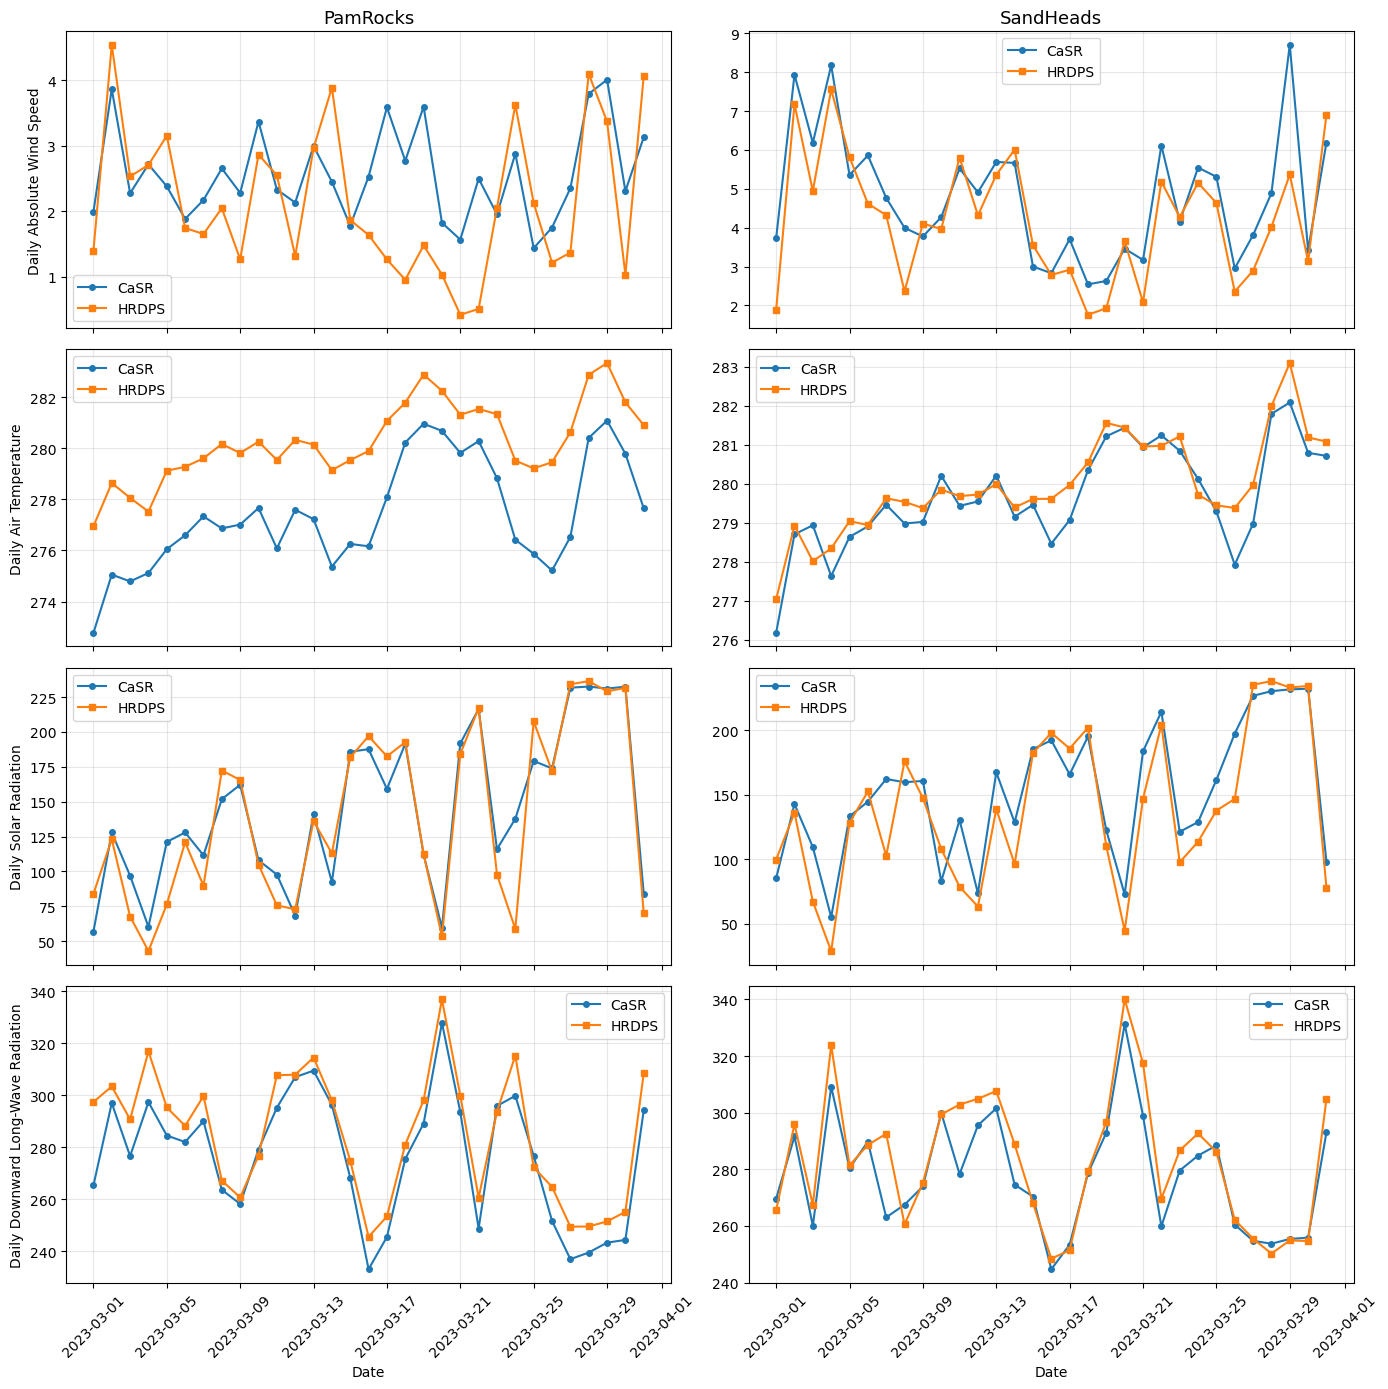

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# File paths
# ============================================================
path_casr_pamrocks = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Analysis_results_comparison/00Mar2023_flux/'
    'CaSR_PamRocks_202303.csv'
)

path_hrdps_pamrocks = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Analysis_results_comparison/00Mar2023_flux/'
    'HRDPS_PamRocks_202303.csv'
)

path_casr_sandheads = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Analysis_results_comparison/00Mar2023_flux/'
    'CaSR_SandHeads_202303.csv'
)

path_hrdps_sandheads = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Analysis_results_comparison/00Mar2023_flux/'
    'HRDPS_SandHeads_202303.csv'
)


# ============================================================
# Read CSV and calculate daily means
# ============================================================
def read_daily_mean(path):
    df = pd.read_csv(path)

    # Convert time to datetime
    df['time_counter'] = pd.to_datetime(df['time_counter'])

    # Absolute wind speed
    df['wind_speed'] = np.sqrt(
        df['u_wind']**2 + df['v_wind']**2
    )

    # Set time as index, then calculate daily mean
    df = df.set_index('time_counter')

    daily = df[
        ['wind_speed', 'tair', 'solar', 'therm_rad']
    ].resample('1D').mean()

    return daily


# ============================================================
# Load all four datasets
# ============================================================
casr_pam = read_daily_mean(path_casr_pamrocks)
hrdps_pam = read_daily_mean(path_hrdps_pamrocks)

casr_sand = read_daily_mean(path_casr_sandheads)
hrdps_sand = read_daily_mean(path_hrdps_sandheads)


# ============================================================
# Plot: 4 variables × 2 locations
# ============================================================
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 14),
    sharex=True
)

variables = [
    ('wind_speed', 'Daily Absolute Wind Speed'),
    ('tair', 'Daily Air Temperature'),
    ('solar', 'Daily Solar Radiation'),
    ('therm_rad', 'Daily Downward Long-Wave Radiation')
]

locations = [
    ('PamRocks', casr_pam, hrdps_pam),
    ('SandHeads', casr_sand, hrdps_sand)
]

for row, (var, ylabel) in enumerate(variables):

    for col, (location, casr, hrdps) in enumerate(locations):

        ax = axes[row, col]

        # CaSR
        ax.plot(
            casr.index,
            casr[var],
            marker='o',
            markersize=4,
            linewidth=1.5,
            label='CaSR'
        )

        # HRDPS
        ax.plot(
            hrdps.index,
            hrdps[var],
            marker='s',
            markersize=4,
            linewidth=1.5,
            label='HRDPS'
        )

        ax.grid(True, alpha=0.3)

        # Location titles only on the top row
        if row == 0:
            ax.set_title(location, fontsize=13)

        # Variable label on left side
        if col == 0:
            ax.set_ylabel(ylabel)

        # Legend
        ax.legend()

        # Rotate dates
        ax.tick_params(axis='x', rotation=45)


# X label on bottom row
axes[-1, 0].set_xlabel('Date')
axes[-1, 1].set_xlabel('Date')


plt.tight_layout()



plt.show()

**I highly suspect that the temperature difference was caused by air-temperature due to land-sea average.**

## Flux Inspection

Would be a good idea to inspect the daily flux time series.

### Flux Data Inspection

In [1]:
import xarray as xr

path_CaSR_flux = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)

path_HRDPS25_flux = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)

flux_casr=xr.open_dataset(path_CaSR_flux)
flux_hrdps=xr.open_dataset(path_HRDPS25_flux)



### Flux time series

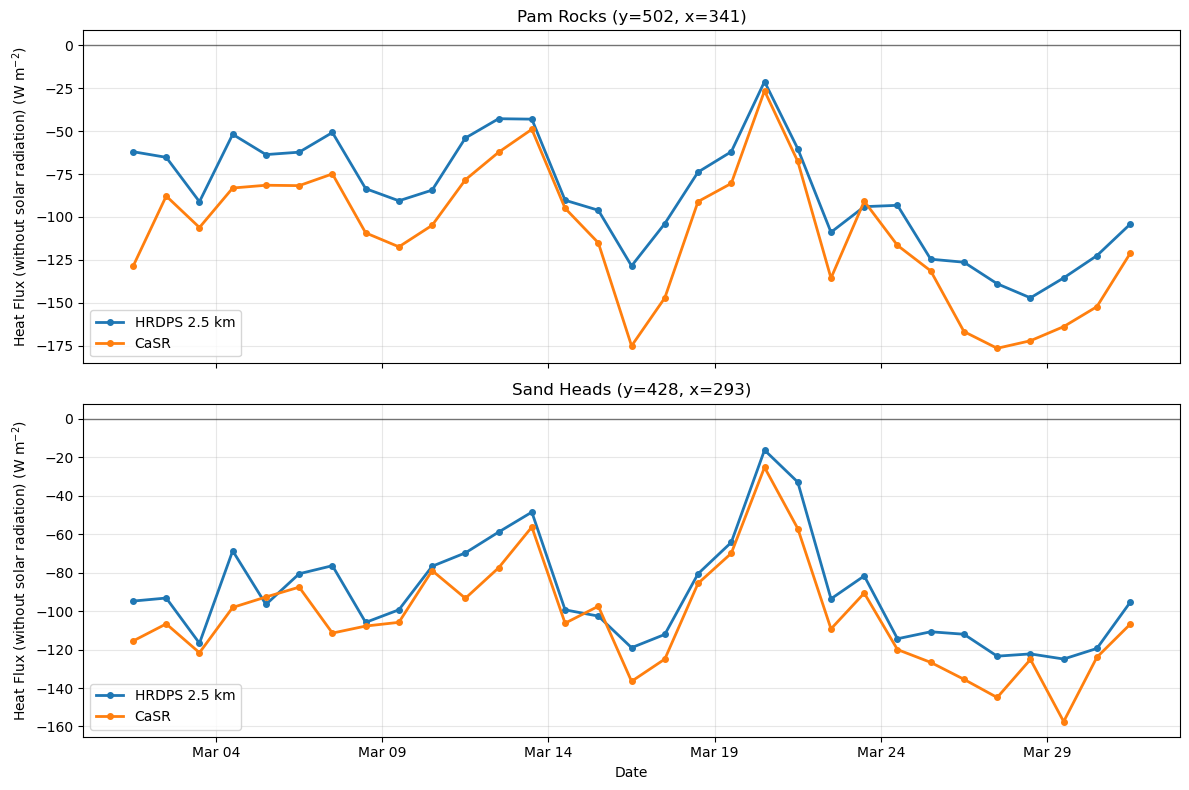

In [3]:
# Heat Flux (without solar radiation)
# Surface Heat Flux Time Series

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# Paths: 1d sbfx_T
# ============================================================
path_CaSR_flux = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)

path_HRDPS25_flux = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
flux_casr = xr.open_dataset(path_CaSR_flux)
flux_hrdps = xr.open_dataset(path_HRDPS25_flux)


# ============================================================
# Stations
# ============================================================
stations = {
    'Pam Rocks': {
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    'Sand Heads': {
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
}


# ============================================================
# Time
# ============================================================
casr_time = flux_casr['time_counter'].values
hrdps_time = flux_hrdps['time_counter'].values


# ============================================================
# Plot
#
# one panel for each station
# ============================================================
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True
)


for ax, (station_name, station) in zip(
    axes,
    stations.items()
):

    y_idx = station['y']
    x_idx = station['x']


    # ========================================================
    # CaSR total surface heat flux
    #
    # Keep the full time_counter dimension
    # ========================================================
    casr_heat = (
        flux_casr['longwave_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_casr['sensible_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_casr['latent_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_casr['emp_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
    ).values


    # ========================================================
    # HRDPS 2.5 km total surface heat flux
    #
    # Keep the full time_counter dimension
    # ========================================================
    hrdps_heat = (
        flux_hrdps['longwave_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_hrdps['sensible_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_hrdps['latent_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
        + flux_hrdps['emp_heat_flux'].isel(
            y=y_idx,
            x=x_idx
        )
    ).values


    # ========================================================
    # Plot
    # ========================================================
    ax.plot(
        hrdps_time,
        hrdps_heat,
        marker='o',
        markersize=4,
        linewidth=2,
        label='HRDPS 2.5 km'
    )

    ax.plot(
        casr_time,
        casr_heat,
        marker='o',
        markersize=4,
        linewidth=2,
        label='CaSR'
    )


    # ========================================================
    # Zero line
    # ========================================================
    ax.axhline(
        0,
        color='k',
        linewidth=1,
        alpha=0.5
    )


    # ========================================================
    # Station title
    # ========================================================
    ax.set_title(
        f"{station_name} "
        f"(y={y_idx}, x={x_idx})"
    )


    # ========================================================
    # Labels
    # ========================================================
    ax.set_ylabel('Heat Flux (without solar radiation) (W m$^{-2}$)')


    # ========================================================
    # Grid
    # ========================================================
    ax.grid(
        True,
        alpha=0.3
    )


    # ========================================================
    # Legend
    # ========================================================
    ax.legend()


# ============================================================
# Date axis
# ============================================================
axes[-1].set_xlabel('Date')

axes[-1].xaxis.set_major_locator(
    mdates.DayLocator(interval=5)
)

axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter('%b %d')
)


plt.tight_layout()

plt.show()


# ============================================================
# Close datasets
# ============================================================
flux_casr.close()
flux_hrdps.close()

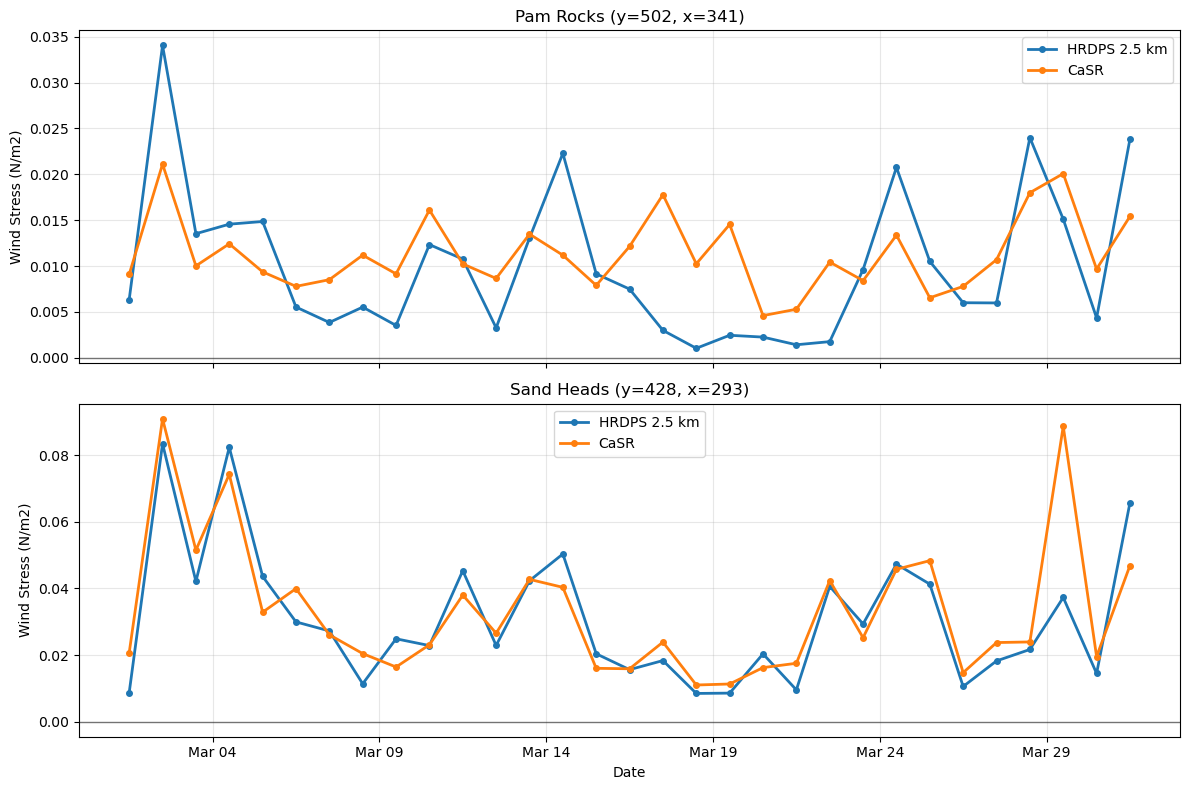

In [5]:
# Wind Stress
# Surface Wind Stress Time Series

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# Paths: 1d sbfx_T
# ============================================================
path_CaSR_flux = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)

path_HRDPS25_flux = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
flux_casr = xr.open_dataset(path_CaSR_flux)
flux_hrdps = xr.open_dataset(path_HRDPS25_flux)


# ============================================================
# Stations
# ============================================================
stations = {
    'Pam Rocks': {
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    'Sand Heads': {
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
}


# ============================================================
# Time
# ============================================================
casr_time = flux_casr['time_counter'].values
hrdps_time = flux_hrdps['time_counter'].values


# ============================================================
# Plot
#
# one panel for each station
# ============================================================
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True
)


for ax, (station_name, station) in zip(
    axes,
    stations.items()
):

    y_idx = station['y']
    x_idx = station['x']


    # ========================================================
    # CaSR total surface stress flux
    #
    # Keep the full time_counter dimension
    # ========================================================
    casr_ws = (
        flux_casr['wind stress'].isel(
            y=y_idx,
            x=x_idx
        )
    ).values


    # ========================================================
    # HRDPS 2.5 km total surface ws flux
    #
    # Keep the full time_counter dimension
    # ========================================================
    hrdps_ws = (
        flux_hrdps['wind stress'].isel(
            y=y_idx,
            x=x_idx
        )
    ).values


    # ========================================================
    # Plot
    # ========================================================
    ax.plot(
        hrdps_time,
        hrdps_ws,
        marker='o',
        markersize=4,
        linewidth=2,
        label='HRDPS 2.5 km'
    )

    ax.plot(
        casr_time,
        casr_ws,
        marker='o',
        markersize=4,
        linewidth=2,
        label='CaSR'
    )


    # ========================================================
    # Zero line
    # ========================================================
    ax.axhline(
        0,
        color='k',
        linewidth=1,
        alpha=0.5
    )


    # ========================================================
    # Station title
    # ========================================================
    ax.set_title(
        f"{station_name} "
        f"(y={y_idx}, x={x_idx})"
    )


    # ========================================================
    # Labels
    # ========================================================
    ax.set_ylabel('Wind Stress (N/m2)')


    # ========================================================
    # Grid
    # ========================================================
    ax.grid(
        True,
        alpha=0.3
    )


    # ========================================================
    # Legend
    # ========================================================
    ax.legend()


# ============================================================
# Date axis
# ============================================================
axes[-1].set_xlabel('Date')

axes[-1].xaxis.set_major_locator(
    mdates.DayLocator(interval=5)
)

axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter('%b %d')
)


plt.tight_layout()

plt.show()


# ============================================================
# Close datasets
# ============================================================
flux_casr.close()
flux_hrdps.close()